In [1]:
!pip install pyspark vaderSentiment -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, re, warnings, joblib
warnings.filterwarnings('ignore')

print("All libraries ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.8 MB/s eta 0:00:00
All libraries ready


In [3]:
from google.colab import files
uploaded = files.upload()
# A button will appear — click it and select reviews_clean.csv from your computer

Saving reviews_clean.csv to reviews_clean.csv


In [4]:
df = pd.read_csv('reviews_clean.csv')
df['Text'] = df['Text'].astype(str)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

Shape: (524587, 16)
Columns: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text', 'year', 'month', 'sentiment', 'sentiment_label', 'text_length', 'word_count']

First 3 rows:


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,year,month,sentiment,sentiment_label,text_length,word_count
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,2011-04-27,Good Quality Dog Food,I have bought several of the Vitality canned d...,2011,4,positive,1,263,48
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,2012-09-07,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,2012,9,negative,0,190,31
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,2008-08-18,"""Delight"" says it all",This is a confection that has been around a fe...,2008,8,positive,1,509,94


In [10]:
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
analyzer   = SentimentIntensityAnalyzer()

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>',    ' ', text)
    text = re.sub(r'http\S+',  ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = [lemmatizer.lemmatize(w) for w in text.split()
              if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

# Use sample for speed
df_nlp = df.sample(n=50000, random_state=42) if len(df) > 50000 else df.copy()
df_nlp = df_nlp.reset_index(drop=True)

print("Preprocessing text — takes 2-3 minutes...")
df_nlp['clean_text'] = df_nlp['Text'].apply(preprocess)
print("Preprocessing done.")

# VADER
print("Running VADER...")
df_nlp['vader_compound']  = df_nlp['Text'].apply(
    lambda x: analyzer.polarity_scores(x)['compound'])
df_nlp['vader_sentiment'] = df_nlp['vader_compound'].apply(
    lambda s: 'positive' if s >= 0.05 else ('negative' if s <= -0.05 else 'neutral'))
print("VADER done.")

print("\n=== VADER DISTRIBUTION ===")
print(df_nlp['vader_sentiment'].value_counts())

# VADER accuracy vs ground truth
vader_check = df_nlp[df_nlp['vader_sentiment'] != 'neutral'].copy()
vader_check['vader_label'] = (vader_check['vader_sentiment'] == 'positive').astype(int)
vader_acc = accuracy_score(vader_check['sentiment_label'], vader_check['vader_label'])
print(f"\nVADER accuracy vs ground truth: {vader_acc:.4f}")
print(f"(on {len(vader_check)} non-neutral reviews)")

Preprocessing text — takes 2-3 minutes...
Preprocessing done.
Running VADER...
VADER done.

=== VADER DISTRIBUTION ===
vader_sentiment
positive    44378
negative     4668
neutral       954
Name: count, dtype: int64

VADER accuracy vs ground truth: 0.8816
(on 49046 non-neutral reviews)


Training NLP Logistic Regression...
Done — F1: 0.9526
Training NLP Naive Bayes...
Done — F1: 0.9359

=== NLP MODEL COMPARISON ===
                        Accuracy        F1   AUC-ROC
NLP Logistic Regression   0.9172  0.952561  0.948861
NLP Naive Bayes           0.8849   0.93591  0.934666
VADER (rule-based)        0.8816       N/A       N/A

Top 10 positive words: ['great', 'love', 'delicious', 'best', 'perfect', 'good', 'excellent', 'favorite', 'nice', 'wonderful']
Top 10 negative words: ['disappointed', 'worst', 'awful', 'disappointing', 'terrible', 'unfortunately', 'stale', 'weak', 'horrible', 'money']


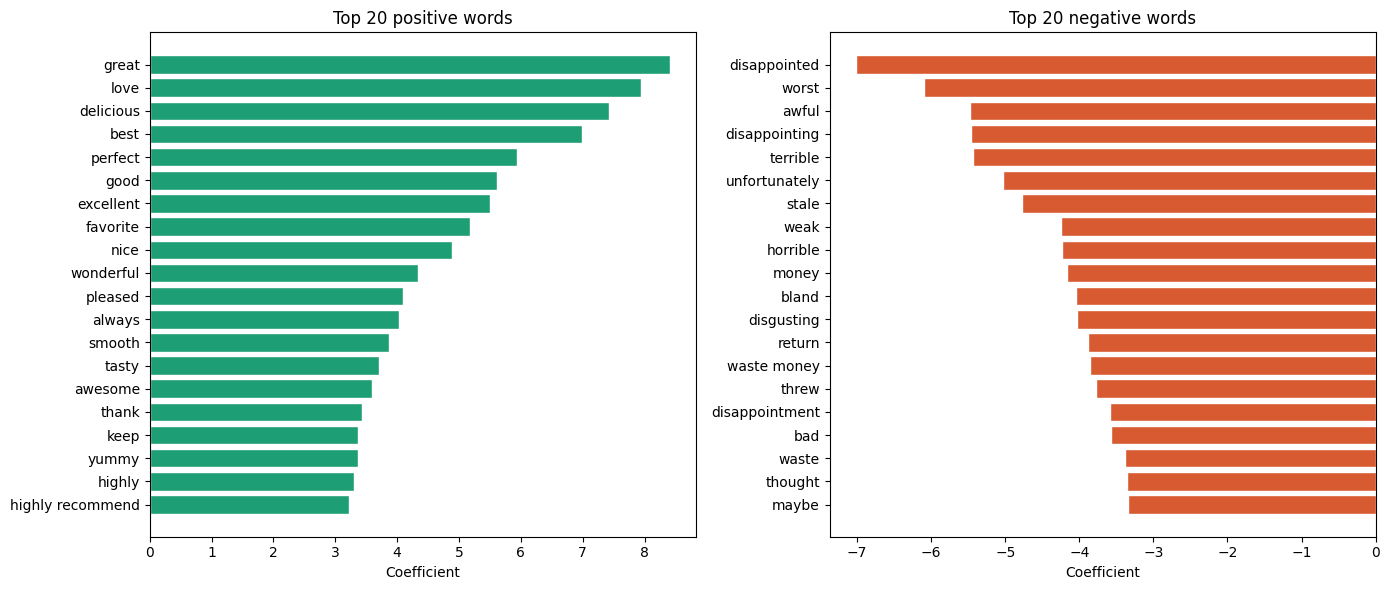

In [11]:
X2 = df_nlp['clean_text']
y2 = df_nlp['sentiment_label']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2)

# Logistic Regression on clean text
print("Training NLP Logistic Regression...")
nlp_lr = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2))),
    ('clf',   LogisticRegression(max_iter=1000, C=1, random_state=42))
])
nlp_lr.fit(X2_train, y2_train)
y2_pred_lr = nlp_lr.predict(X2_test)
print("Done — F1:", round(f1_score(y2_test, y2_pred_lr), 4))

# Naive Bayes on clean text
print("Training NLP Naive Bayes...")
nlp_nb = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2))),
    ('clf',   MultinomialNB())
])
nlp_nb.fit(X2_train, y2_train)
y2_pred_nb = nlp_nb.predict(X2_test)
print("Done — F1:", round(f1_score(y2_test, y2_pred_nb), 4))

print("\n=== NLP MODEL COMPARISON ===")
nlp_results = pd.DataFrame({
    'NLP Logistic Regression': {
        'Accuracy': accuracy_score(y2_test, y2_pred_lr),
        'F1':       f1_score(y2_test, y2_pred_lr),
        'AUC-ROC':  roc_auc_score(y2_test, nlp_lr.predict_proba(X2_test)[:,1])
    },
    'NLP Naive Bayes': {
        'Accuracy': accuracy_score(y2_test, y2_pred_nb),
        'F1':       f1_score(y2_test, y2_pred_nb),
        'AUC-ROC':  roc_auc_score(y2_test, nlp_nb.predict_proba(X2_test)[:,1])
    },
    'VADER (rule-based)': {
        'Accuracy': round(vader_acc, 4),
        'F1':       'N/A',
        'AUC-ROC':  'N/A'
    }
}).T
print(nlp_results)

# Top positive and negative words
feature_names = nlp_lr.named_steps['tfidf'].get_feature_names_out()
coefs         = nlp_lr.named_steps['clf'].coef_[0]
top_pos = [(feature_names[i], round(coefs[i],3)) for i in coefs.argsort()[-20:][::-1]]
top_neg = [(feature_names[i], round(coefs[i],3)) for i in coefs.argsort()[:20]]

print("\nTop 10 positive words:", [w for w,_ in top_pos[:10]])
print("Top 10 negative words:", [w for w,_ in top_neg[:10]])

# Chart
fig, axes = plt.subplots(1, 2, figsize=(14,6))
axes[0].barh([w for w,_ in top_pos][::-1], [c for _,c in top_pos][::-1],
             color='#1D9E75', edgecolor='white')
axes[0].set_title('Top 20 positive words')
axes[0].set_xlabel('Coefficient')

axes[1].barh([w for w,_ in top_neg][::-1], [c for _,c in top_neg][::-1],
             color='#D85A30', edgecolor='white')
axes[1].set_title('Top 20 negative words')
axes[1].set_xlabel('Coefficient')

plt.tight_layout()
plt.savefig('figures/top_words.png', dpi=150)
plt.show()

In [12]:
error_df = pd.DataFrame({
    'text':       X2_test.values,
    'true':       y2_test.values,
    'predicted':  y2_pred_lr,
    'confidence': nlp_lr.predict_proba(X2_test).max(axis=1).round(4)
})

fp = error_df[(error_df['true']==0) & (error_df['predicted']==1)]
fn = error_df[(error_df['true']==1) & (error_df['predicted']==0)]

print(f"Total false positives: {len(fp)}")
print(f"Total false negatives: {len(fn)}")

print("\n=== 5 FALSE POSITIVES (model said positive, actually negative) ===")
for _, r in fp.head(5).iterrows():
    print(f"\n  Confidence: {r['confidence']}")
    print(f"  Text: {r['text'][:150]}...")

print("\n=== 5 FALSE NEGATIVES (model said negative, actually positive) ===")
for _, r in fn.head(5).iterrows():
    print(f"\n  Confidence: {r['confidence']}")
    print(f"  Text: {r['text'][:150]}...")

Total false positives: 697
Total false negatives: 131

=== 5 FALSE POSITIVES (model said positive, actually negative) ===

  Confidence: 0.9005
  Text: bought gingerbread get christmasfeeling delivered fast gingerbread seemed really fresh normally love quite old something...

  Confidence: 0.8229
  Text: soft used sugar bake one layer firm pound cake like layer cake intended decoration wilton butter cake recipe pretty hardy cake stand change temperatur...

  Confidence: 0.7876
  Text: purchased apple year old son love today farm freeze dried apple since unavailable amazon last month trying different replacement third alternative pur...

  Confidence: 0.7233
  Text: wanted love salty impossible enjoy bugle salty year ago increase salt...

  Confidence: 0.9675
  Text: like commercial dog food eukanuba mostly garbage full product filler grain dog need health certainly worst dog food far best absolutely worth anywher ...

=== 5 FALSE NEGATIVES (model said negative, actually positive) ===



In [13]:
# Generate predictions on full nlp sample
df_nlp['predicted_label']     = nlp_lr.predict(df_nlp['clean_text'])
df_nlp['predicted_sentiment'] = df_nlp['predicted_label'].apply(
    lambda x: 'positive' if x==1 else 'negative')
df_nlp['confidence']          = nlp_lr.predict_proba(
    df_nlp['clean_text']).max(axis=1).round(4)

# Keep columns needed for dashboard
keep_cols = ['Text','sentiment','sentiment_label',
             'predicted_sentiment','predicted_label','confidence',
             'vader_compound','vader_sentiment']

if 'year'  in df_nlp.columns: keep_cols.append('year')
if 'month' in df_nlp.columns: keep_cols.append('month')

final = df_nlp[keep_cols].copy()
final.to_csv('final_predictions.csv', index=False)

results_df.to_csv('model_results.csv')
joblib.dump(nlp_lr, 'best_model.pkl')

print("Saved:")
print("  final_predictions.csv — shape:", final.shape)
print("  model_results.csv")
print("  best_model.pkl")
final.head(3)

Saved:
  final_predictions.csv — shape: (50000, 10)
  model_results.csv
  best_model.pkl


,Text,sentiment,sentiment_label,predicted_sentiment,predicted_label,confidence,vader_compound,vader_sentiment,year,month
0,"This cake is light, fluffy, and chocolatey. We...",positive,1,positive,1,0.9506,0.9264,positive,2012,1
1,"These are still very tasty, but since the last...",positive,1,positive,1,0.6888,0.5023,positive,2011,10
2,This coconut oil is a great oil for the hair. ...,positive,1,positive,1,0.9583,0.9311,positive,2011,1


In [2]:
from google.colab import files

download_list = [
    'final_predictions.csv',
    'model_results.csv',
    'best_model.pkl',
    'figures/sentiment_distribution.png',
    'figures/wordcount_distribution.png',
    'figures/reviews_per_year.png',
    'figures/correlation_heatmap.png',
    'figures/roc_curves.png',
    'figures/confusion_matrix.png',
    'figures/top_words.png',
]

for f in download_list:
    try:
        files.download(f)
        print("Downloaded:", f)
    except:
        print("Skipped (not found):", f)

print("\nAll done! Move files into your project:")
print("  CSVs          → data/clean/")
print("  best_model    → models/")
print("  PNG figures   → reports/figures/")

Skipped (not found): final_predictions.csv
Skipped (not found): model_results.csv
Skipped (not found): best_model.pkl
Skipped (not found): figures/sentiment_distribution.png
Skipped (not found): figures/wordcount_distribution.png
Skipped (not found): figures/reviews_per_year.png
Skipped (not found): figures/correlation_heatmap.png
Skipped (not found): figures/roc_curves.png
Skipped (not found): figures/confusion_matrix.png
Skipped (not found): figures/top_words.png

All done! Move files into your project:
  CSVs          → data/clean/
  best_model    → models/
  PNG figures   → reports/figures/
